## Import Libraries

In [3]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
def show(img): 
    plt.figure(figsize=(4,4)) 
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

## Image Preprocessing

In [5]:
def preprocessing_image(img):  
    
    img = cv2.imread(img) 
    if img is None: 
        print("Image not found!")  

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
    print("GrayScale")
    show(gray)
    
    Blur = cv2.GaussianBlur(gray, (5,5), 0) 
    print('Blur')
    show(Blur)
    
    Canny = cv2.Canny(Blur, 30, 150) 
    print('Canny')
    show(Canny)
    
    Dilated = cv2.dilate(Canny, (1,1), iterations=2) 
    print('Dilated')
    show(Dilated)
    
    Contour, _ = cv2.findContours(Canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 
    Contour_img = img.copy() 

    RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    cv2.drawContours(RGB, Contour, -1, (123,0,123), 2)  
    print('DrawContour')
    show(RGB)
    print('coins in the image: ', len(Contour)) 

GrayScale


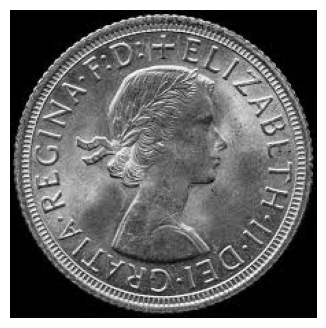

Blur


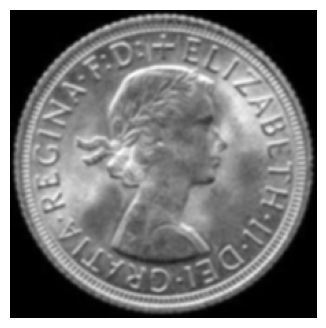

Canny


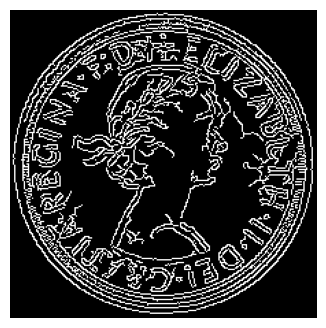

Dilated


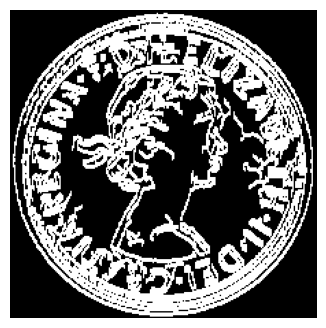

DrawContour


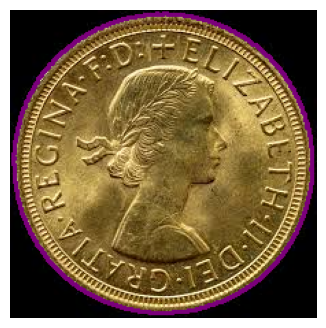

coins in the image:  1


In [6]:
img = 'coins.jpg'
preprocessing_image(img)

GrayScale


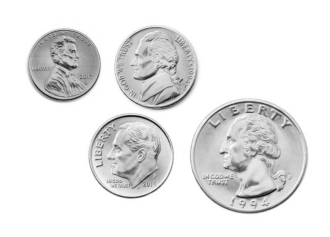

Blur


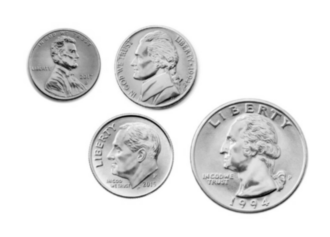

Canny


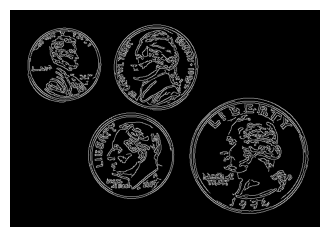

Dilated


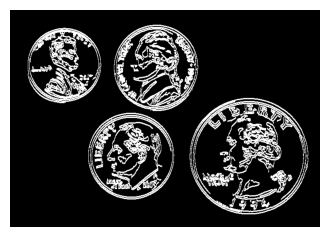

DrawContour


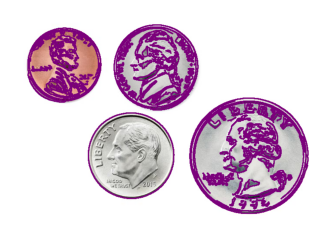

coins in the image:  245


In [7]:
img1 = 'coins1.jpg' 
preprocessing_image(img1)

## Webcam 

In [8]:
cap = cv2.VideoCapture(0)

while True:
    ret, img = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9,9), 0)

    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=100,
        param1=120,
        param2=50,
        minRadius=50,
        maxRadius=150
    )

    count = 0

    if circles is not None:
        circles = np.uint16(np.around(circles))

        for x, y, r in circles[0]:
            cv2.circle(img, (x, y), r, (0,255,0), 2)
            cv2.circle(img, (x, y), 2, (0,0,255), 3)
            count += 1

    cv2.putText(img, f'Coins: {count}',
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,255,0),
                2)

    cv2.imshow('Circle Detection', img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()